# COSC2753 Assignment 2 - Fashion Intelligence System
## Group 8:
- s3927120 - Vu Quoc Gia Quan
- sid - name
- sid - name
- sid - name

## Objective:  
- Doing Exploratory Data Analysis and preprocessing on train dataset



## I. Exploratory Data Analysis

### 1. Import Libraries

In [1]:
import json
import pickle
import hashlib
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.stats import chi2_contingency

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold

import torch
from torch.utils.data import Dataset, WeightedRandomSampler
import torchvision.transforms as T

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)

### 2. Load Dataset

In [2]:
DATA_DIR = Path("../data/raw/FashionDataset")
OUT_DIR = Path("../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR = DATA_DIR / "test" / "images_test"

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING'}] {p}")

[OK] ..\data\raw\FashionDataset\train\styles_train.csv
[OK] ..\data\raw\FashionDataset\train\images_train
[OK] ..\data\raw\FashionDataset\test\styles_prediction.csv
[OK] ..\data\raw\FashionDataset\test\images_test


## 3. Checking "style_train.csv" and images in the train dataset

#### 3.1 First look at the CSV

In [3]:
df = pd.read_csv(TRAIN_CSV)
print(df.columns.tolist())
print(df.shape)
df.head(3)

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'Unnamed: 10', 'Unnamed: 11']
(38617, 12)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,Unnamed: 10,Unnamed: 11
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,NaN,NaN
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,NaN,NaN
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,NaN,NaN


In [4]:
# The raw CSV has stray commas in some rows, which pandas turns into extra
# 'Unnamed: N' columns. Drop them.
unnamed_cols = df.columns[df.columns.str.startswith('Unnamed')].tolist()
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
print(f"Dropped {len(unnamed_cols)} malformed column(s): {unnamed_cols}")
print(df.columns.tolist())
print(df.shape)

Dropped 2 malformed column(s): ['Unnamed: 10', 'Unnamed: 11']
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']
(38617, 10)


There are 2 unnamed and empty collumns so they will be removed

#### 3.2 Image check using csv file

Checking if any image file in "style_train.csv" doesn't match up with actual image

In [5]:
csv_ids = set(df['id'].astype(str))
disk_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob("*.jpg")}

missing_images = sorted(csv_ids - disk_ids)   # CSV rows with no image file
extra_images = sorted(disk_ids - csv_ids)     # image files with no CSV row

print(f"CSV rows with no image file: {len(missing_images)} -> {missing_images}")
print(f"Image files with no CSV row: {len(extra_images)}")

CSV rows with no image file: 5 -> ['12347', '39401', '39403', '39410', '39425']
Image files with no CSV row: 0


There are 5 csv row with no image file. These will be removed from the csv file.

In [6]:
# Drop the unmatched rows now, before the split, so 'df' and its image folder
# stay aligned for every downstream step (EDA, split, processing).
df = df[~df['id'].astype(str).isin(missing_images)].reset_index(drop=True)
df['id'] = df['id'].astype(str).str.strip()
print(f"Remaining rows: {df.shape[0]}")

Remaining rows: 38612


#### 3.3 Image integrity: corrupt files

In [7]:
corrupt = []
for img_id in df['id']:
    try:
        with Image.open(IMAGES_TRAIN_DIR / f"{img_id}.jpg") as im:
            im.verify()
    except Exception as e:
        corrupt.append((img_id, str(e)))

print(f"Corrupt/unopenable images: {len(corrupt)}")
for img_id, err in corrupt[:10]:
    print(f"  {img_id}: {err}")

# Drop them if any turn up -- a no-op on the current data (0 corrupt), but it means
# the pipeline doesn't silently carry an unreadable file into the Dataset.
if corrupt:
    df = df[~df['id'].isin({i for i, _ in corrupt})].reset_index(drop=True)
    print(f"Dropped {len(corrupt)} corrupt row(s). Remaining: {len(df)}")

Corrupt/unopenable images: 0


There are no corrupt image after checking so nothing was removed.

#### 3.4 Exact-duplicate images

**MODIFY - this subsection now removes duplicates instead of only tagging them.** Hashing
every file finds rows whose image is byte-for-byte identical to another row's. Previously
these rows were kept and only used as a grouping key for the split; keeping them means the
same photo is counted several times in every distribution plot, is seen several times per
epoch during training, and inflates whatever score the duplicated classes get. They are now
dropped, so the rest of the notebook works on one row per unique image.

Before dropping anything we check the labels, because a duplicate group is only safe to
collapse if its rows agree on what the image is.


In [8]:
# MODIFY: hashing now feeds an explicit de-duplication (three cells below), not just a
# grouping key for the split. 'dup_group' is still kept as a column so the split can be
# grouped on it as a cheap safety net.
# Exact duplicate images (byte-for-byte, via md5 hash). The resulting 'dup_group'
# is needed later: it's what the train/val split is grouped on, so two copies of
# the same product photo can never end up on opposite sides of the split.
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hash_to_group = {}
group_ids = []
for img_id in df['id']:
    h = file_hash(IMAGES_TRAIN_DIR / f"{img_id}.jpg")
    if h not in hash_to_group:
        hash_to_group[h] = img_id       # first id seen becomes the group label
    group_ids.append(hash_to_group[h])

df['dup_group'] = group_ids
n_groups = df['dup_group'].nunique()
n_dupe_rows = len(df) - n_groups
print(f"{n_groups} unique image groups out of {len(df)} rows "
      f"({n_dupe_rows} rows are exact duplicates of another row)")

37849 unique image groups out of 38612 rows (763 rows are exact duplicates of another row)


**Label check.** For every duplicate group, do all its rows carry the same
`articleType`, `gender`, `season` and `usage`? Where they don't, identical pixels have been
given two different answers, so at most one of them is right and nothing in the data says
which.

In [9]:
for target in ['articleType', 'gender', 'season', 'usage']:
    label_conflicts = df.groupby('dup_group')[target].nunique(dropna=False)
    conflicting_groups = label_conflicts[label_conflicts > 1]
    print(f"{target}: {len(conflicting_groups)} of {n_groups} groups have inconsistent labels")

articleType: 7 of 37849 groups have inconsistent labels
gender: 7 of 37849 groups have inconsistent labels
season: 8 of 37849 groups have inconsistent labels
usage: 3 of 37849 groups have inconsistent labels


In [10]:
conflict_ids = set()
for target in ['articleType', 'gender', 'season', 'usage']:
    lc = df.groupby('dup_group')[target].nunique(dropna=False)
    conflict_ids |= set(lc[lc > 1].index)

print(f"{len(conflict_ids)} distinct dup_groups have a conflict in at least one target")

20 distinct dup_groups have a conflict in at least one target


In [11]:
conflict_rows = df[df['dup_group'].isin(conflict_ids)].sort_values('dup_group')
conflict_rows[['id', 'dup_group', 'articleType', 'gender', 'season', 'usage', 'productDisplayName']]

,id,dup_group,articleType,gender,season,usage,productDisplayName
8200,11346,11346,Jeans,Men,Spring,Casual,Lee Men Blue Zed Fit Jeans
8201,11347,11346,Jeans,Men,Summer,Casual,Lee Men Elvira Rinse Blue Chicago Fit Jeans
2,1165,1165,Tshirts,Men,Summer,Sports,Nike Mean Team India Cricket Jersey
2873,5062,1165,Watches,Men,Winter,Casual,Being Human Men Black Dial Steel Plated Strap ...
9087,12345,12345,Sarees,Women,Spring,Ethnic,Xoxo Women Maroon Pure Georgette Solid Ready-t...
9088,12346,12345,Tshirts,Women,Fall,Formal,Reebok Women Grey Solid V-Neck T-shirt
9926,13307,13306,Trousers,Men,Fall,Casual,Gini and Jony Kids Solid Black Trousers
9925,13306,13306,Trousers,Boys,Fall,Casual,Gini and Jony Kids Solid Black Trousers
14288,18592,18580,Socks,Men,Fall,Sports,Puma Men Sport Quarters Pack of 3 Socks
14276,18580,18580,Socks,Men,Summer,Sports,Puma Men Sport Quarters Pack of 3 Socks


Looking at the conflicting groups above, they split into two kinds: harmless
near-misses (the same trousers labelled `Men` in one row and `Boys` in another) and rows that
are plainly wrong (one group is `Tshirts` in one row and `Watches` in another - the two rows
share a file, so one of them has the wrong image attached). Neither kind can be resolved from
the data alone, and there are only 20 such groups, so the whole group is dropped rather than
guessing a winner. Every other group collapses to a single row.

In [12]:
# MODIFY: new -- actually de-duplicate the dataset.
#   1. Drop every row in a dup_group whose target labels disagree (ambiguous ground truth).
#   2. Collapse every remaining dup_group to its first row.
n_conflict_rows_dropped = int(df['dup_group'].isin(conflict_ids).sum())
df = df[~df['dup_group'].isin(conflict_ids)].reset_index(drop=True)

n_duplicate_rows_dropped = len(df) - df['dup_group'].nunique()
df = df.drop_duplicates(subset='dup_group', keep='first').reset_index(drop=True)

assert df['dup_group'].is_unique, "de-duplication left more than one row per image"
print(f"Dropped {n_conflict_rows_dropped} row(s) in {len(conflict_ids)} label-conflicting groups")
print(f"Dropped {n_duplicate_rows_dropped} redundant copy row(s)")
print(f"Rows remaining (one per unique image): {len(df)}")

Dropped 41 row(s) in 20 label-conflicting groups
Dropped 742 redundant copy row(s)
Rows remaining (one per unique image): 37829


#### 3.5 Quick visual sanity check

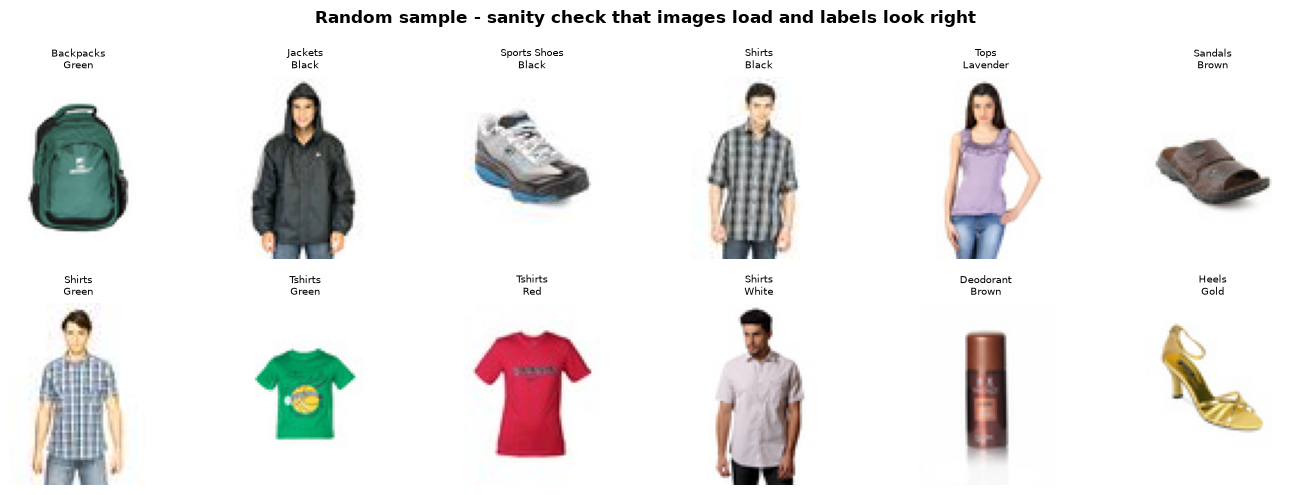

In [13]:
sample = df.sample(12, random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, (_, r) in zip(axes.flat, sample.iterrows()):
    ax.imshow(Image.open(IMAGES_TRAIN_DIR / f"{r['id']}.jpg"))
    ax.axis("off")
    ax.set_title(f"{r['articleType']}\n{r['baseColour']}", fontsize=7)
fig.suptitle("Random sample - sanity check that images load and labels look right", fontweight="bold")
plt.tight_layout()
plt.show()

### 4. Exploring the Data

**MODIFY - this section used to run after the train/validation split, on `train_data` only.**
It now runs on the whole de-duplicated training file, before any split. Two reasons:

- The split is a modelling decision, and Section II.2 compares candidate stratification keys
  before committing to one. Splitting first and exploring afterwards meant that comparison
  came after the thing it was supposed to inform.
- Nothing in this section is *fitted*. It counts, plots and cross-tabulates; it produces no
  threshold, encoder or statistic that is later applied to data. Everything that *is* fitted -
  the rare-class thresholds (Section II.5), the label encoders (Section II.7) and the
  normalisation statistics (Section II.9) - still uses train rows only, after the split.
  That, not the scope of the plots, is where validation leakage would actually come from.

The file being explored here is the supplied training set; the marked test set is never
touched in this notebook.

#### 4.1 Structure & overview

In [14]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
print(df.columns.tolist())
print(df.shape)
df.head()

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'dup_group']
(37829, 11)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,dup_group
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,1163
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,1164
2,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,1525
3,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,1526
4,1528,Men,Apparel,Topwear,Jackets,Black,Fall,2010,Sports,Puma Men Ferrari Black Fleece Jacket,1528


In [15]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37829 entries, 0 to 37828
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  37829 non-null  str  
 1   gender              37829 non-null  str  
 2   masterCategory      37829 non-null  str  
 3   subCategory         37829 non-null  str  
 4   articleType         37829 non-null  str  
 5   baseColour          37816 non-null  str  
 6   season              37809 non-null  str  
 7   year                37829 non-null  int64
 8   usage               37758 non-null  str  
 9   productDisplayName  37822 non-null  str  
 10  dup_group           37829 non-null  str  
dtypes: int64(1), str(10)
memory usage: 3.2 MB


#### 4.2 Missing values check

In [16]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct.round(2)}).sort_values('missing', ascending=False)
missing_df

,missing,pct
usage,71,0.19
season,20,0.05
baseColour,13,0.03
productDisplayName,7,0.02
masterCategory,0,0.00
id,0,0.00
gender,0,0.00
subCategory,0,0.00
articleType,0,0.00
year,0,0.00


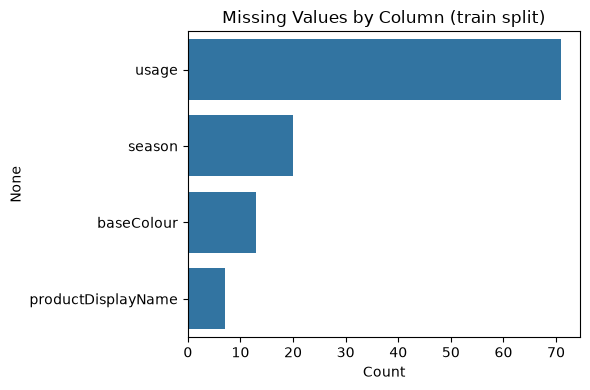

In [17]:
nonzero_missing = missing[missing > 0].sort_values(ascending=False)
if len(nonzero_missing):
    plt.figure(figsize=(6, 4))
    sns.barplot(x=nonzero_missing.values, y=nonzero_missing.index)
    plt.title('Missing Values by Column (train split)')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()

#### 4.3 Duplicate rows in metadata

In [18]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate ids: {df['id'].duplicated().sum()}")

Duplicate rows: 0
Duplicate ids: 0


#### 4.4 Category distributions

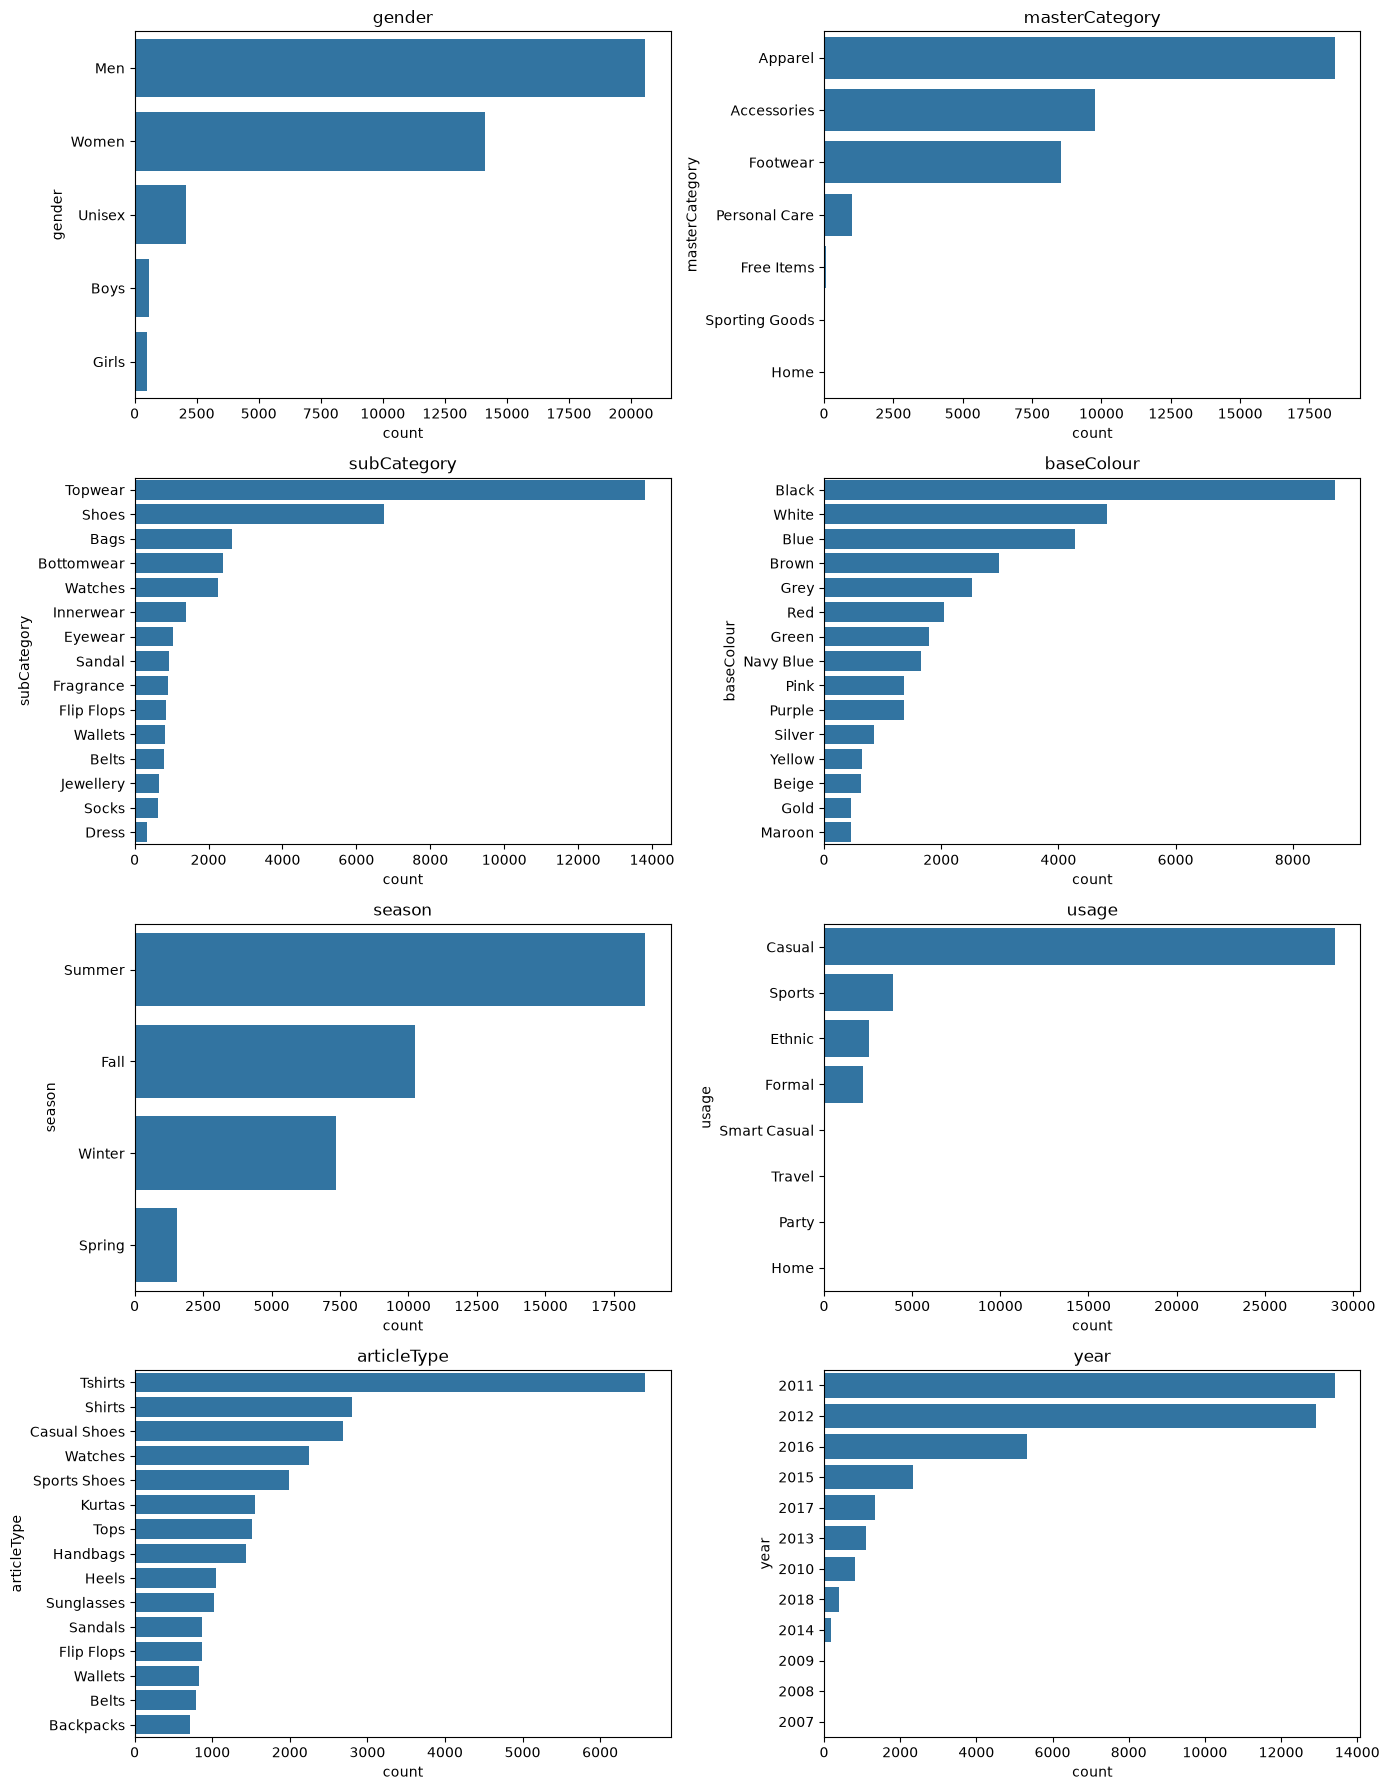

In [19]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
cat_cols = ['gender', 'masterCategory', 'subCategory', 'baseColour', 'season', 'usage', 'articleType', 'year']
fig, axes = plt.subplots(4, 2, figsize=(14, 18))  # 4x2 = 8 axes, one per cat_col
for ax, col in zip(axes.flatten(), cat_cols):
    order = df[col].value_counts().index[:15]  # top 15 to keep it readable
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [20]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
print("Category distributions (summary):\n")
for col in cat_cols:
    vc = df[col].value_counts()
    top_val, top_count = vc.index[0], vc.iloc[0]
    top_pct = top_count / len(df) * 100
    n_classes = vc.shape[0]
    least_val, least_count = vc.index[-1], vc.iloc[-1]
    print(f"- {col}: {n_classes} categories. "
          f"Most common is '{top_val}' ({top_count} items, {top_pct:.1f}%). "
          f"Least common is '{least_val}' ({least_count} items).")

Category distributions (summary):

- gender: 5 categories. Most common is 'Men' (20576 items, 54.4%). Least common is 'Girls' (483 items).
- masterCategory: 7 categories. Most common is 'Apparel' (18409 items, 48.7%). Least common is 'Home' (1 items).
- subCategory: 41 categories. Most common is 'Topwear' (13818 items, 36.5%). Least common is 'Vouchers' (1 items).
- baseColour: 46 categories. Most common is 'Black' (8715 items, 23.0%). Least common is 'Rose' (3 items).
- season: 4 categories. Most common is 'Summer' (18653 items, 49.3%). Least common is 'Spring' (1558 items).
- usage: 8 categories. Most common is 'Casual' (28964 items, 76.6%). Least common is 'Home' (1 items).
- articleType: 124 categories. Most common is 'Tshirts' (6582 items, 17.4%). Least common is 'Lounge Tshirts' (1 items).
- year: 12 categories. Most common is '2011' (13408 items, 35.4%). Least common is '2007' (2 items).


#### 4.5 Closer check at "articleType"

In [21]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
vc = df['articleType'].value_counts()
print(f"Distinct articleType classes in train: {df['articleType'].nunique()}")
print(f"Classes with fewer than 10 samples: {(vc < 10).sum()}")
print(f"Classes with fewer than 5 samples:  {(vc < 5).sum()}")
vc.head(15)

Distinct articleType classes in train: 124
Classes with fewer than 10 samples: 32
Classes with fewer than 5 samples:  21


articleType
Tshirts         6582
Shirts          2799
Casual Shoes    2680
Watches         2248
Sports Shoes    1989
Kurtas          1556
Tops            1519
Handbags        1437
Heels           1045
Sunglasses      1029
Sandals          864
Flip Flops       863
Wallets          827
Belts            794
Backpacks        710
Name: count, dtype: int64

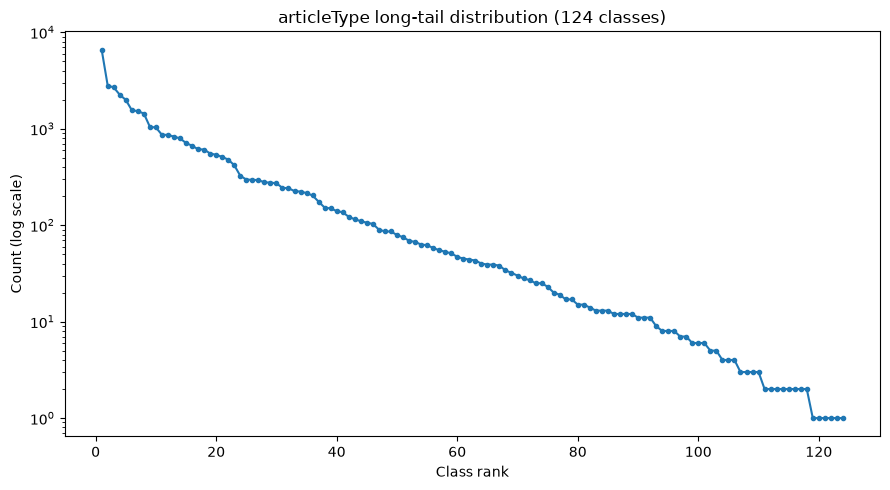

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(vc) + 1), vc.values, marker='o', markersize=3)
ax.set_yscale('log')
ax.set_xlabel('Class rank')
ax.set_ylabel('Count (log scale)')
ax.set_title(f'articleType long-tail distribution ({len(vc)} classes)')
plt.tight_layout()
plt.show()

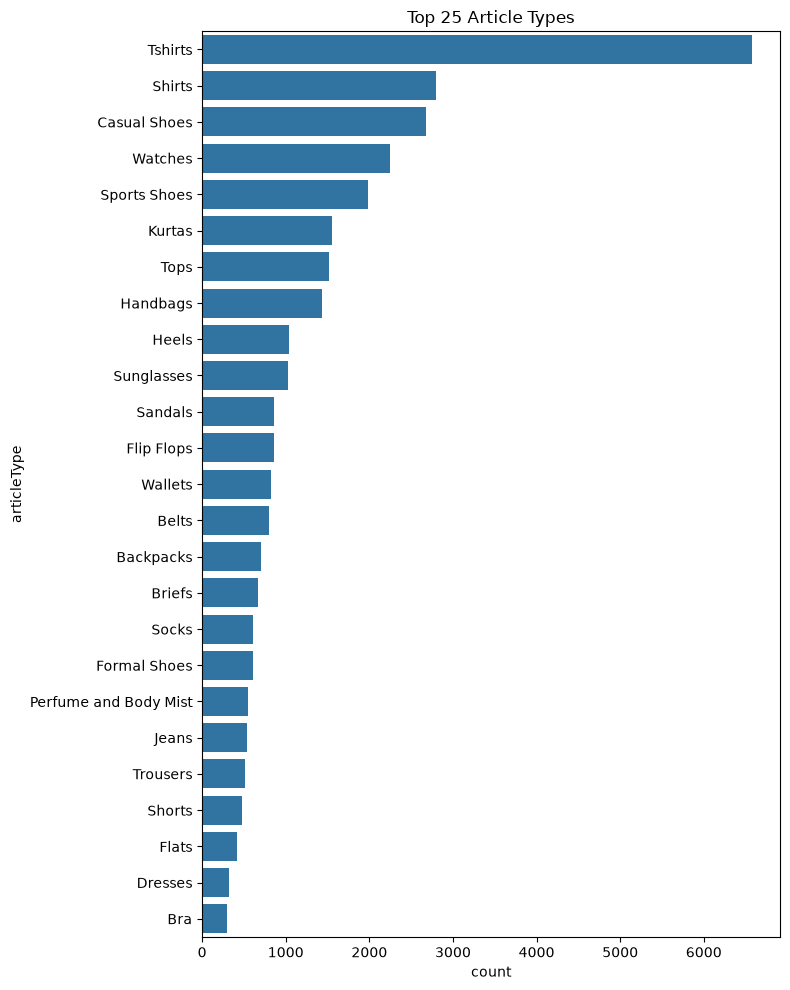

In [23]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
N = 25
plt.figure(figsize=(8, 10))
top_article = df['articleType'].value_counts().index[:N]
sns.countplot(data=df, y='articleType', order=top_article)
plt.title(f'Top {N} Article Types')
plt.tight_layout()
plt.show()

#### 4.6 Year distribution & outliers

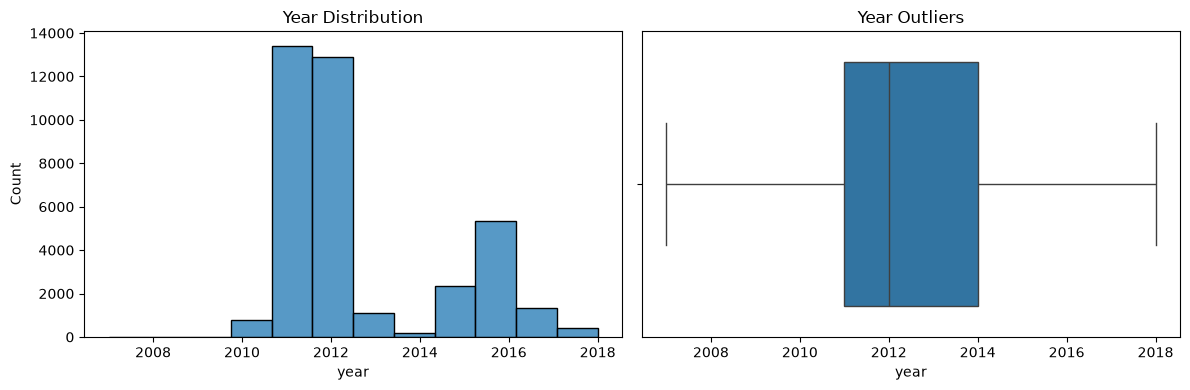

In [24]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['year'], bins=df['year'].nunique(), ax=axes[0])
axes[0].set_title('Year Distribution')
sns.boxplot(x=df['year'], ax=axes[1])
axes[1].set_title('Year Outliers')
plt.tight_layout()
plt.show()

In [25]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
year_counts = df['year'].value_counts().sort_index()

q1 = df['year'].quantile(0.25)
q3 = df['year'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_years = df[(df['year'] < lower_bound) | (df['year'] > upper_bound)]['year']
outlier_summary = outlier_years.value_counts().sort_index()

print(f"Data spans {df['year'].min():.0f} to {df['year'].max():.0f}.")
print(f"Most items are from {year_counts.idxmax():.0f} ({year_counts.max()} items).")
print(f"Outlier years (IQR rule): {outlier_summary.to_dict()}")

Data spans 2007 to 2018.
Most items are from 2011 (13408 items).
Outlier years (IQR rule): {}


#### 4.7 Cramér's V - how strongly the feature columns are related

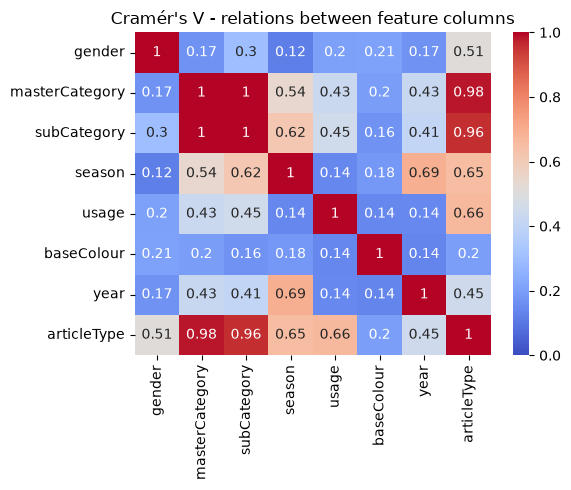

In [26]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

# 'productDisplayName' is deliberately excluded: it is near-unique free text (28,954
# distinct values), so its crosstab is enormous and Cramer's V against it is ~1 by
# construction -- it measures uniqueness, not a real association.
feature_cols = ['gender', 'masterCategory', 'subCategory', 'season',
                'usage', 'baseColour', 'year', 'articleType']
corr_matrix = pd.DataFrame(index=feature_cols, columns=feature_cols, dtype=float)
for c1, c2 in combinations(feature_cols, 2):
    v = cramers_v(df[c1], df[c2])
    corr_matrix.loc[c1, c2] = v
    corr_matrix.loc[c2, c1] = v
for c in feature_cols:
    corr_matrix.loc[c, c] = 1.0

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix.astype(float), annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér's V - relations between feature columns")
plt.tight_layout()
plt.show()

#### 4.8 Target distributions & relationships between targets

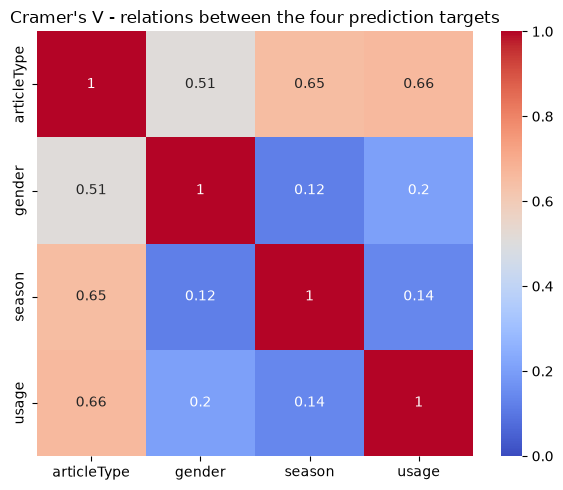

In [27]:
targets = ['articleType', 'gender', 'season', 'usage']

# All four targets are already in `corr_matrix` from 5.7 -- slice it rather than
# recomputing the same chi-square tests.
target_corr = corr_matrix.loc[targets, targets].astype(float)

plt.figure(figsize=(6, 5))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramer's V - relations between the four prediction targets")
plt.tight_layout()
plt.show()


Strongest target relationship: articleType vs usage (Cramér's V = 0.66)


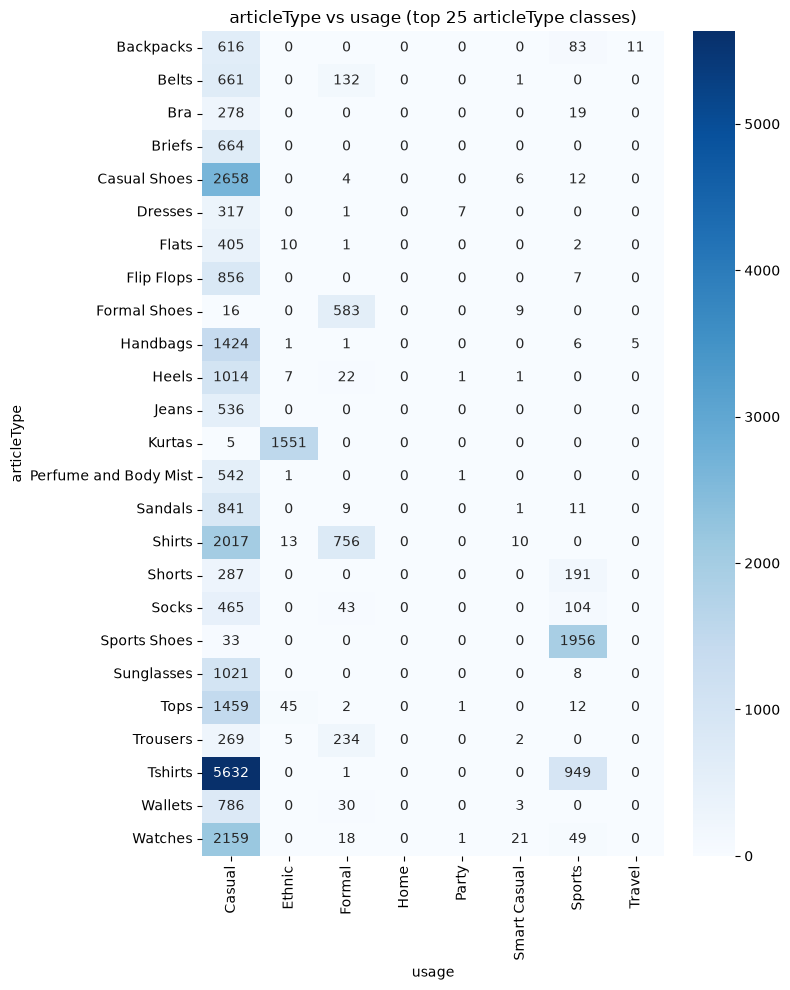

In [28]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
# The strongest target-target relationship, viewed as a crosstab heatmap
strongest_pair = target_corr.where(~np.eye(len(targets), dtype=bool)).stack().idxmax()
c1, c2 = strongest_pair
print(f"Strongest target relationship: {c1} vs {c2} (Cramér's V = {target_corr.loc[c1, c2]:.2f})")

plt.figure(figsize=(8, 10))
ct = pd.crosstab(df[c1], df[c2])
top_types = df[c1].value_counts().index[:25]
sns.heatmap(ct.loc[ct.index.intersection(top_types)], annot=True, fmt='d', cmap='Blues')
plt.title(f'{c1} vs {c2} (top 25 {c1} classes)')
plt.tight_layout()
plt.show()

#### 4.9 How imbalanced are the classes

In [29]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
def imbalance_summary(series, name):
    vc = series.dropna().value_counts()
    ratio = vc.max() / vc.min()
    return {
        'target': name,
        'n_classes': len(vc),
        'majority_class': vc.idxmax(),
        'majority_count': int(vc.max()),
        'minority_class': vc.idxmin(),
        'minority_count': int(vc.min()),
        'imbalance_ratio': round(ratio, 1),
    }

imbalance_table = pd.DataFrame([
    imbalance_summary(df['gender'], 'gender'),
    imbalance_summary(df['season'], 'season'),
    imbalance_summary(df['usage'], 'usage'),
    imbalance_summary(df['articleType'], 'articleType'),
])
imbalance_table

,target,n_classes,majority_class,majority_count,minority_class,minority_count,imbalance_ratio
0,gender,5,Men,20576,Girls,483,42.6
1,season,4,Summer,18653,Spring,1558,12.0
2,usage,8,Casual,28964,Home,1,28964.0
3,articleType,124,Tshirts,6582,Shoe Laces,1,6582.0


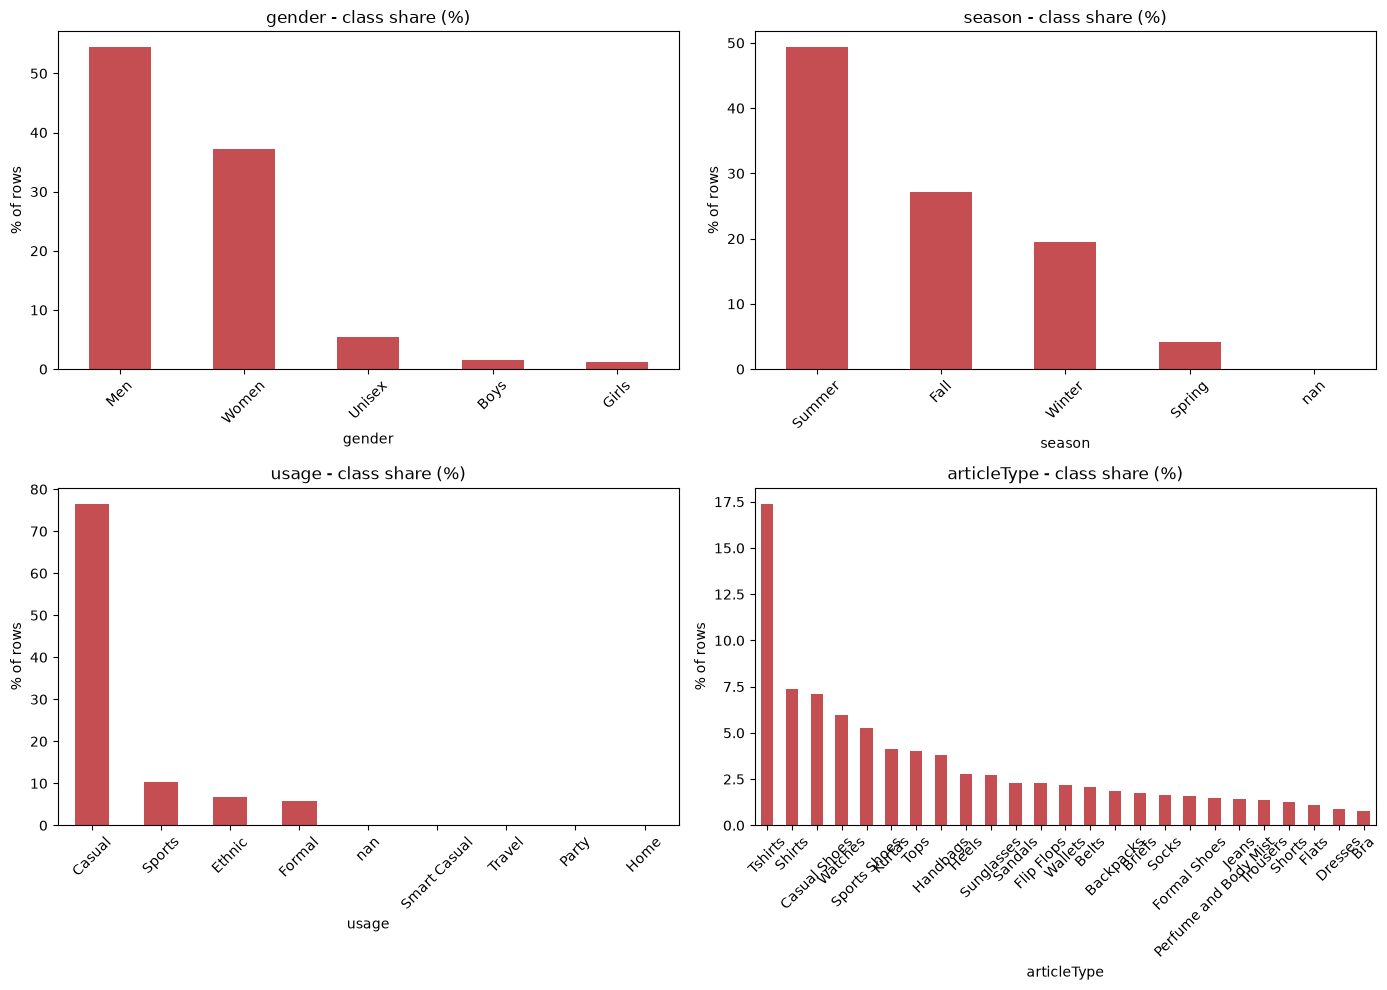

In [30]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ['gender', 'season', 'usage', 'articleType']):
    shares = df[col].value_counts(normalize=True, dropna=False) * 100
    if col == 'articleType':
        shares = shares.head(25)
    shares.plot(kind='bar', ax=ax, color='#C44E52')
    ax.set_ylabel('% of rows')
    ax.set_title(f'{col} - class share (%)')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#### 4.10 Checking the images: size, color mode, file size (full dataset)

In [31]:
# MODIFY: runs on the full de-duplicated `df` (pre-split), not `train_data`.
def profile_images(ids, folder):
    rows = []
    for img_id in ids:
        p = folder / f"{img_id}.jpg"
        try:
            with Image.open(p) as im:      # reads header only, fast
                w, h, mode = im.size[0], im.size[1], im.mode
        except Exception:
            w = h = None
            mode = "ERR"
        rows.append({"id": img_id, "w": w, "h": h, "mode": mode,
                     "kb": round(p.stat().st_size / 1024, 2)})
    return pd.DataFrame(rows)

imgs_train = profile_images(df['id'], IMAGES_TRAIN_DIR)
print("Most common dimensions (train):")
print(imgs_train.groupby(['w', 'h']).size().sort_values(ascending=False).head())
print("\nColour mode counts (train):", imgs_train['mode'].value_counts().to_dict())

Most common dimensions (train):
w   h 
60  80    37812
53  80        8
60  60        5
    77        2
    76        1
dtype: int64

Colour mode counts (train): {'RGB': 37487, 'L': 342}


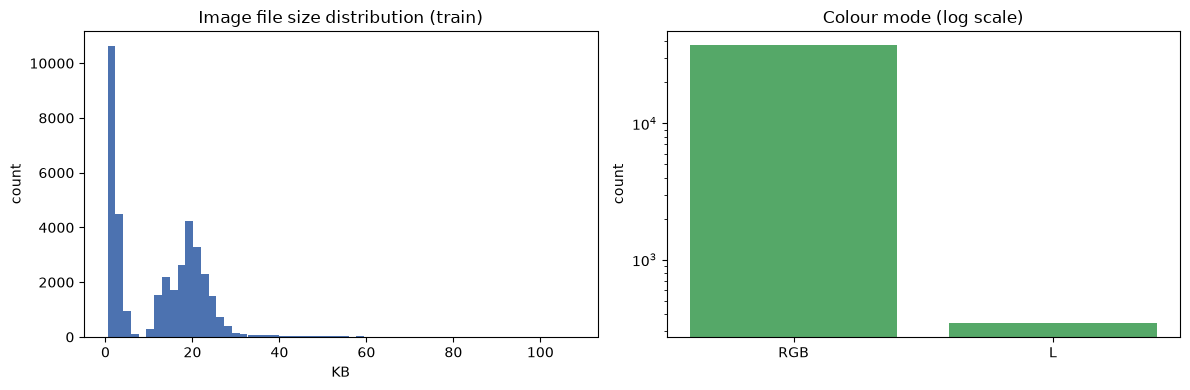

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(imgs_train["kb"], bins=60, color="#4C72B0")
ax[0].set(title="Image file size distribution (train)", xlabel="KB", ylabel="count")

mode_counts = imgs_train["mode"].value_counts()
ax[1].bar(mode_counts.index.astype(str), mode_counts.values, color="#55A868")
ax[1].set_yscale("log")
ax[1].set(title="Colour mode (log scale)", ylabel="count")
plt.tight_layout()
plt.show()

**MODIFY - findings updated for the de-duplicated, pre-split dataset (~37.8k rows).**
Exact counts refresh when the notebook is re-run; the picture itself is unchanged:

- Images are almost all a consistent 60x80 pixels, with a handful of size outliers.
- A few hundred images are grayscale (`L` mode) rather than colour - these need converting to
  RGB before going into a CNN (done in the transform pipeline, Section II.10).
- File sizes are mostly small (under 25 KB), and no image failed the integrity check.
- `articleType` has a long tail: dozens of classes with fewer than 10 samples. Addressed in
  Section II.5.
- `usage` is roughly three-quarters `Casual`, and `gender` is mostly `Men`/`Women` - both
  handled by the imbalance fix in Section II.8.
- None of the feature and target columns are strongly linked enough to drop any of them.

## II. Preprocessing data

This section builds the four datasets (`articleType`, `season`, `gender`, `usage`) that Tasks 1-3 will train on, and explains the reasoning behind each decision.

### 1 Basic cleaning


In [33]:
def clean_dataframe(data):
    """Whitespace-strip categorical/text columns, coerce year to numeric,
    and fill non-target missing values with a placeholder. Fit-free - safe
    to reuse on train, val, or a future test split."""
    data = data.copy()

    # Note: 'articleType_grouped' isn't in this list -- it doesn't exist yet at this point
    # in the pipeline (created in Section II.5, after the split), and it derives from
    # already-cleaned 'articleType'/'subCategory' values, so it needs no separate stripping.
    cat_cols = ['gender', 'masterCategory', 'subCategory', 'articleType',
                'baseColour', 'season', 'usage', 'productDisplayName']
    for c in cat_cols:
        if c in data.columns:
            data[c] = data[c].astype('string').str.strip()

    if 'year' in data.columns:
        data['year'] = pd.to_numeric(data['year'], errors='coerce')

    # baseColour / productDisplayName aren't prediction targets, so missing values
    # here don't block any task - fill rather than drop.
    for c in ['baseColour', 'productDisplayName']:
        if c in data.columns:
            data[c] = data[c].fillna('Unknown')

    return data

# MODIFY: cleaning now runs once on `df`, before the split, instead of separately on
# train_data and val_data afterwards. The function is fit-free -- it strips whitespace,
# coerces a dtype and fills two non-target columns -- so running it on the pooled data
# cannot leak anything, and it means the split sees consistent values.
df = clean_dataframe(df)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
id                     0
gender                 0
masterCategory         0
subCategory            0
articleType            0
baseColour             0
season                20
year                   0
usage                 71
productDisplayName     0
dup_group              0
dtype: int64


### 2. Choosing the split strategy

**MODIFY - moved here from after the split, and it now decides the split rather than just
commenting on it.** Two questions have to be answered before splitting: *one split or one per
task*, and *stratified on what*.

**One split, not one per task.** With a separate split per task, a row can be training data
for Task 1 and validation data for Task 2. Any model that consumes another task's output -
as the chained pipeline does - is then evaluated on rows it was trained on. One shared split
removes that failure mode entirely, so the only remaining question is whether a single key can
keep all four targets balanced at once.

**Candidate keys.** The cell below builds stratification keys of increasing granularity and
reports, for each, the **worst-case gap between the train and validation proportion of every
target class**, in percentage points. A gap of 0 means the split preserves that column's
distribution exactly. Stratifying on `masterCategory x season x gender x usage` targets all
four columns simultaneously; the risk is fragmentation, since with enough columns most strata
end up too small for `StratifiedGroupKFold`. Rare combinations therefore **back off** to
progressively coarser keys, so no row is dropped for being in a small stratum.

Stratifying on the target columns is not leakage: a stratified split uses labels by
definition, and both sides keep their own labels. What must stay train-only is anything
*fitted* - thresholds, encoders, pixel statistics - and all of that comes after the split.

**A note on `dup_group`.** After Section I.3.3 there is exactly one row per unique image, so
grouping is now a formality. It is kept because it costs nothing and would catch any
duplicate re-introduced by an upstream change.

In [34]:
# MODIFY: this comparison now runs BEFORE the split and its winner is what Section II.5
# actually uses. `build_stratify_key` is reused by the split cell, so this cell must run.
def build_stratify_key(frame, cols, min_stratum=4):
    """Composite stratification key. Rare combinations back off to a coarser key
    instead of being dropped, so every row keeps a stratum."""
    key = frame[cols].fillna('NA').astype(str).agg('|'.join, axis=1)
    for level in range(len(cols) - 1, 0, -1):
        vc = key.value_counts()
        rare = set(vc[vc < min_stratum].index)
        if not rare:
            break
        coarse = frame[cols[:level]].fillna('NA').astype(str).agg('|'.join, axis=1) + f'|<L{level}>'
        key = key.where(~key.isin(rare), coarse)
    # Final catch-all. Note a plain '<rare>' bucket is not enough: if only two rows remain
    # rare, that bucket is itself below min_stratum and StratifiedGroupKFold warns and
    # places them arbitrarily. Merge the stragglers into the largest existing stratum,
    # which is guaranteed big enough to absorb them.
    vc = key.value_counts()
    rare = set(vc[vc < min_stratum].index)
    if rare:
        largest = vc.idxmax()
        key = key.where(~key.isin(rare), largest)
    assert key.value_counts().min() >= min_stratum, "a stratum is still below min_stratum"
    return key


def split_balance(frame, key, targets):
    """Worst-case train-vs-val gap (percentage points) for each target column."""
    sgkf_probe = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
    tr_idx, va_idx = next(sgkf_probe.split(frame, key, groups=frame['dup_group']))
    tr, va = frame.iloc[tr_idx], frame.iloc[va_idx]
    assert not set(tr['dup_group']) & set(va['dup_group']), "duplicate group spans the split"
    out = {}
    for t in targets:
        a = tr[t].value_counts(normalize=True, dropna=False)
        b = va[t].value_counts(normalize=True, dropna=False)
        out[t] = round(a.sub(b, fill_value=0).abs().max() * 100, 3)
    return out


# Raw `usage`, not `usage_grouped`: the grouped column is derived from train-only counts
# AFTER the split, so using it to build the split would be circular.
TARGETS = ['masterCategory', 'season', 'gender', 'usage']
CANDIDATE_KEYS = {
    'masterCategory only (previous)':     ['masterCategory'],
    'season only (old per-task split)':   ['season'],
    'masterCategory x season':            ['masterCategory', 'season'],
    'masterCategory x season x gender':   ['masterCategory', 'season', 'gender'],
    'all four (composite, chosen)':       ['masterCategory', 'season', 'gender', 'usage'],
}

rows = []
for label, cols in CANDIDATE_KEYS.items():
    key = build_stratify_key(df, cols)
    row = {'stratify_on': label, 'n_strata': int(key.nunique()),
           'backed_off_rows': int(key.str.contains('<', regex=False).sum())}
    row.update(split_balance(df, key, TARGETS))
    rows.append(row)

strat_comparison = pd.DataFrame(rows).set_index('stratify_on')
print("Worst-case train-vs-val gap per target column, in percentage points")
print("(lower is better; 0 = distribution preserved exactly)\n")
display(strat_comparison)

current = strat_comparison.loc['masterCategory only (previous)']
best = strat_comparison.loc['all four (composite, chosen)']
print(f"Season gap under the masterCategory-only split    : {current['season']:.3f} pp")
print(f"Season gap under a composite key                  : {best['season']:.3f} pp")
print(f"Gender gap under the masterCategory-only split     : {current['gender']:.3f} pp")
print(f"Gender gap under a composite key                   : {best['gender']:.3f} pp")
print(f"Usage gap under the masterCategory-only split      : {current['usage']:.3f} pp")
print(f"Usage gap under a composite key                    : {best['usage']:.3f} pp")
print(f"Worst gap across ALL four targets, composite key   : {best[TARGETS].max():.3f} pp")
print(f"Rows lost to fragmentation with the composite key  : 0 "
      f"({int(best['backed_off_rows'])} rows sit in a backed-off stratum)")
print("\nThe composite key is the one used by the split in Section II.3.")

Worst-case train-vs-val gap per target column, in percentage points
(lower is better; 0 = distribution preserved exactly)



,n_strata,backed_off_rows,masterCategory,season,gender,usage
stratify_on,,,,,,
masterCategory only (previous),6,0,0.011,1.147,0.967,0.798
season only (old per-task split),5,0,0.489,0.009,1.982,0.389
masterCategory x season,19,0,0.011,0.020,0.693,0.575
masterCategory x season x gender,64,9,0.047,0.051,0.032,0.417
"all four (composite, chosen)",152,66,0.025,0.051,0.084,0.029


Season gap under the masterCategory-only split    : 1.147 pp
Season gap under a composite key                  : 0.051 pp
Gender gap under the masterCategory-only split     : 0.967 pp
Gender gap under a composite key                   : 0.084 pp
Usage gap under the masterCategory-only split      : 0.798 pp
Usage gap under a composite key                    : 0.029 pp
Worst gap across ALL four targets, composite key   : 0.084 pp
Rows lost to fragmentation with the composite key  : 0 (66 rows sit in a backed-off stratum)

The composite key is the one used by the split in Section II.3.


### 3. Train / Validation Split

**What we do:** one `StratifiedGroupKFold` split (about 75/25), stratified on the composite
`masterCategory x season x gender x usage` key from Section II.2 and grouped on `dup_group`.
One split serves all four tasks.

**MODIFY - the stratification key changed from `masterCategory` alone to the composite key.**
The old choice was defensible on its own terms - `masterCategory` has few categories and all
of them are large - but the comparison above shows the composite key holds every target within
a fraction of a percentage point, including `season`, at no cost in rows. The back-off also
removes the need for the old "drop `masterCategory` values with fewer than `n_splits` rows"
step: tiny strata are merged upward instead of having their rows deleted, so the single `Home`
row that used to be discarded is kept.

**Why `articleType` is not in the key:** it has many rare classes, and deciding which count as
rare from the pooled data would use validation labels to set up training. That decision is
made after the split, from train counts only (Section II.5).

**Why one split and not k-fold cross-validation:** with ~28k training rows a single holdout is
stable enough, and 4-fold would mean training every model four times - time better spent on
the models themselves.

**Anything trained before this notebook is re-run is no longer comparable**, since the rows in
each side of the split have changed.

In [35]:
# MODIFY: stratify on the composite key chosen in Section II.2 (was: masterCategory alone).
# The old "drop masterCategory categories with < n_splits rows" step is gone -- build_stratify_key
# backs rare combinations off into a larger stratum, so no row is dropped to make the split work.
STRATIFY_COLS = ['masterCategory', 'season', 'gender', 'usage']

sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)  # 1 fold ~= 25%
stratify_key = build_stratify_key(df, STRATIFY_COLS, min_stratum=sgkf.get_n_splits())

train_idx, val_idx = next(sgkf.split(df, stratify_key, groups=df['dup_group']))
train_data = df.iloc[train_idx].reset_index(drop=True)
val_data = df.iloc[val_idx].reset_index(drop=True)

print(f"Train: {train_data.shape[0]}, Val: {val_data.shape[0]}")

# --- sanity checks ---
overlap = set(train_data['dup_group']) & set(val_data['dup_group'])
print(f"Duplicate-image groups appearing in BOTH splits: {len(overlap)} (should be 0)")

missing_master = set(df['masterCategory'].unique()) - set(train_data['masterCategory'].unique())
print(f"masterCategory classes missing from train: {missing_master if missing_master else 'none'}")

for col in ['masterCategory', 'season', 'gender', 'usage']:
    a = train_data[col].value_counts(normalize=True, dropna=False)
    b = val_data[col].value_counts(normalize=True, dropna=False)
    print(f"{col}: worst train-vs-val gap = {a.sub(b, fill_value=0).abs().max() * 100:.3f} pp")

Train: 28371, Val: 9458
Duplicate-image groups appearing in BOTH splits: 0 (should be 0)
masterCategory classes missing from train: {'Home'}
masterCategory: worst train-vs-val gap = 0.025 pp
season: worst train-vs-val gap = 0.051 pp
gender: worst train-vs-val gap = 0.084 pp
usage: worst train-vs-val gap = 0.029 pp


### 4. What to do about missing values, per task

`season` and `usage` are prediction targets, so we can't fill in a missing value without just guessing a label. Rows missing those values get dropped, but only for that one task - not from the shared `train_data`/`val_data`. `articleType` and `gender` have no missing values. This is handled in Section II.6, where we build a separate dataset for each task.

### 5. Handling rare classes, per task

**`articleType`** - this is worked out using train data only, so validation rows are never looked at. Classes with too few samples get relabelled to their own `subCategory` instead of a single "Other" bucket. For example, a rare class like "Rain Trousers" becomes "Bottomwear". This keeps more useful information than dumping everything into one catch-all label. One trade-off worth mentioning in the report: this mixes two levels of detail in one column - some rows keep a specific label like "T-shirts", others become a broader one like "Bottomwear" after being redistributed. A validation row whose `articleType` never appears in train at all (so it can't be judged "rare" from train counts, since it has zero train count, not just a low one) gets caught and dropped automatically later, at the label-encoding step in Section II.7 - not handled here, so this step never has to look at validation data.

In [36]:
# (The class counts themselves were shown in Section I.4.5 -- this cell only sweeps
# candidate thresholds to justify the value picked below.)
vc_article = train_data['articleType'].value_counts()

for thresh in [5, 10, 15, 20, 30, 50]:
    kept_classes = (vc_article >= thresh).sum()
    kept_rows = vc_article[vc_article >= thresh].sum()
    print(f"threshold={thresh:>3}: classes kept={kept_classes:>3}/{len(vc_article)}, "
          f"rows kept={kept_rows:>6} ({kept_rows/len(train_data)*100:.1f}% of train)")


threshold=  5: classes kept= 99/121, rows kept= 28325 (99.8% of train)
threshold= 10: classes kept= 83/121, rows kept= 28209 (99.4% of train)
threshold= 15: classes kept= 75/121, rows kept= 28115 (99.1% of train)
threshold= 20: classes kept= 72/121, rows kept= 28061 (98.9% of train)
threshold= 30: classes kept= 64/121, rows kept= 27865 (98.2% of train)
threshold= 50: classes kept= 55/121, rows kept= 27524 (97.0% of train)


In [37]:
ARTICLE_TYPE_MIN_COUNT = 20  # keeps most classes while dropping the near-unlearnable long tail

rare_article_types = set(vc_article[vc_article < ARTICLE_TYPE_MIN_COUNT].index)

def apply_article_type_grouping(data, rare_set):
    """Redistributes rare articleType rows into their own subCategory, rather than a
    single 'Other' bucket. `rare_set` is fixed from train-only counts and applied as-is
    to both splits -- never recomputed from val."""
    data = data.copy()
    rare_mask = data['articleType'].isin(rare_set)
    data['articleType_grouped'] = data['articleType']
    data.loc[rare_mask, 'articleType_grouped'] = data.loc[rare_mask, 'subCategory']
    return data

train_data = apply_article_type_grouping(train_data, rare_article_types)
val_data = apply_article_type_grouping(val_data, rare_article_types)

print(f"Rare articleType classes folded into subCategory: {len(rare_article_types)}")
print("Classes after grouping (train):", train_data['articleType_grouped'].nunique())
print("\nRare rows redistributed into (train):")
print(train_data.loc[train_data['articleType'].isin(rare_article_types), 'articleType_grouped'].value_counts())

Rare articleType classes folded into subCategory: 49
Classes after grouping (train): 93

Rare rows redistributed into (train):
articleType_grouped
Bottomwear                  61
Topwear                     34
Makeup                      25
Bags                        24
Lips                        24
Shoe Accessories            18
Accessories                 16
Nails                       14
Sports Equipment            13
Gloves                      13
Apparel Set                  9
Innerwear                    9
Headwear                     8
Dress                        8
Water Bottle                 6
Socks                        6
Eyes                         6
Wristbands                   4
Umbrellas                    4
Loungewear and Nightwear     4
Sports Accessories           2
Cufflinks                    1
Vouchers                     1
Name: count, dtype: Int64


In [38]:
# Verify the redistribution actually fixed the imbalance -- if a subCategory a rare
# articleType got folded into is itself still small, the long tail has moved, not gone.
post_counts = train_data['articleType_grouped'].value_counts()
still_rare = post_counts[post_counts < ARTICLE_TYPE_MIN_COUNT]
print(f"articleType_grouped classes still below {ARTICLE_TYPE_MIN_COUNT} samples after redistribution: {len(still_rare)}")
if len(still_rare):
    print(still_rare)
    print("\nNOTE: the long tail has been reduced but not eliminated -- the smallest classes\n"
          "here still have single-digit support. Report macro-F1 per class so this is visible,\n"
          "and treat these classes' scores as unreliable rather than as model failure.")

articleType_grouped classes still below 20 samples after redistribution: 16
articleType_grouped
Shoe Accessories            18
Accessories                 16
Nails                       14
Sports Equipment            13
Gloves                      13
Apparel Set                  9
Innerwear                    9
Headwear                     8
Dress                        8
Water Bottle                 6
Eyes                         6
Wristbands                   4
Umbrellas                    4
Loungewear and Nightwear     4
Sports Accessories           2
Vouchers                     1
Name: count, dtype: Int64

NOTE: the long tail has been reduced but not eliminated -- the smallest classes
here still have single-digit support. Report macro-F1 per class so this is visible,
and treat these classes' scores as unreliable rather than as model failure.


**`usage`** doesn't have a parent column to redistribute into, so rare classes here go
into a single `Other` bucket. The three classes folded in account for 66 rows between
them, so `Other` stays small enough not to distort the remaining four classes. Same
train-only approach as `articleType`:


In [39]:
USAGE_MIN_COUNT = 100

vc_usage = train_data['usage'].value_counts()
for thresh in [10, 25, 50, 100, 150]:
    kept_classes = (vc_usage >= thresh).sum()
    kept_rows = vc_usage[vc_usage >= thresh].sum()
    print(f"threshold={thresh:>3}: classes kept={kept_classes}/{len(vc_usage)}, "
          f"rows kept={kept_rows} ({kept_rows/train_data['usage'].notna().sum()*100:.1f}% of usage rows)")

threshold= 10: classes kept=7/7, rows kept=28319 (100.0% of usage rows)
threshold= 25: classes kept=5/7, rows kept=28290 (99.9% of usage rows)
threshold= 50: classes kept=4/7, rows kept=28248 (99.7% of usage rows)
threshold=100: classes kept=4/7, rows kept=28248 (99.7% of usage rows)
threshold=150: classes kept=4/7, rows kept=28248 (99.7% of usage rows)


In [40]:
rare_usage = vc_usage[vc_usage < USAGE_MIN_COUNT].index

for d in (train_data, val_data):
    d['usage_grouped'] = d['usage'].where(~d['usage'].isin(rare_usage), 'Other')

print("usage classes after grouping (train):", train_data['usage_grouped'].nunique())
print(train_data['usage_grouped'].value_counts())

usage classes after grouping (train): 5
usage_grouped
Casual    21721
Sports     2948
Ethnic     1925
Formal     1654
Other        71
Name: count, dtype: Int64


**`gender`** and **`season`** don't need any merging. `gender` has 5 classes and `season` has 4. Both are imbalanced (see Section I.4.9), but every class still has enough samples to split, encode, and learn from without needing to combine categories.

### 6. One dataset per task

In [41]:
# Column actually used as the prediction target for each task
target_columns = {
    'articleType': 'articleType_grouped',
    'season': 'season',
    'gender': 'gender',
    'usage': 'usage_grouped',
}

def usable_subset(data, target_col):
    return data[data[target_col].notna()].reset_index(drop=True)

train_usable = {t: usable_subset(train_data, col) for t, col in target_columns.items()}
val_usable = {t: usable_subset(val_data, col) for t, col in target_columns.items()}

for t in target_columns:
    print(f"{t}: train usable={len(train_usable[t])}, val usable={len(val_usable[t])}")

articleType: train usable=28371, val usable=9458
season: train usable=28357, val usable=9452
gender: train usable=28371, val usable=9458
usage: train usable=28319, val usable=9439


### 7. Turning labels into numbers

Each task gets its own label encoder, fit on train data only - since each task drops different rows, one shared encoder wouldn't make sense across all of them. If validation ever has a label the encoder never saw in train (shouldn't happen after our split, but we check anyway), that row gets flagged and dropped instead of silently causing an error.

In [42]:
# MODIFY: `label_maps` removed -- it duplicated encoder.classes_ and was only ever
# read by the print at the bottom of this cell. Section 11 writes the same mapping
# to label_mappings/*.json directly from the encoders.
encoders = {}

for t, col in target_columns.items():
    le = LabelEncoder()
    le.fit(train_usable[t][col])
    encoders[t] = le

    train_usable[t][col + '_enc'] = le.transform(train_usable[t][col])

    val_known = val_usable[t][val_usable[t][col].isin(le.classes_)]
    dropped = len(val_usable[t]) - len(val_known)
    if dropped:
        print(f"WARNING: dropped {dropped} val rows for '{t}' - label(s) not seen in train")
    val_usable[t] = val_known.reset_index(drop=True)
    val_usable[t][col + '_enc'] = le.transform(val_usable[t][col])

    print(f"{t}: {len(le.classes_)} classes"
          + (f" -> {list(le.classes_)}" if len(le.classes_) <= 6 else ""))

articleType: 93 classes
season: 4 classes -> ['Fall', 'Spring', 'Summer', 'Winter']
gender: 5 classes -> ['Boys', 'Girls', 'Men', 'Unisex', 'Women']
usage: 5 classes -> ['Casual', 'Ethnic', 'Formal', 'Other', 'Sports']


### 8. Fixing class imbalance

**Options we thought about:** giving rare classes more weight in the loss function, oversampling them, or augmenting their images. Using all three together tends to over-correct, so we picked one consistent approach for all four tasks instead of tuning something different for each.

**What we're using: `WeightedRandomSampler`**, together with the augmentation from Section II.10. This is built from training rows only - validation is never resampled, so it still reflects the real, imbalanced distribution.

- **Why not also weight the loss function:** once the sampler is already balancing each batch, adding loss weighting on top would double-punish the common classes - risky for `articleType`, where some of those weights would be very small. We calculate class weights below just for reference, but don't actually use them in training.
- **Why the sampler needs augmentation:** the sampler picks the same rare-class images again and again (with replacement). Without variation, the model could just memorize those exact images instead of learning to generalize. Augmentation (flip, rotate, adjust color - Section II.10) makes each repeat draw look a bit different.
- **Why not SMOTE:** SMOTE blends pixels between different photos to make synthetic examples, which for product photos just produces unrealistic-looking images. Augmentation does the same job in a way that makes sense for images.
- **One more thing to track:** always look at macro-F1 next to accuracy in the modelling notebooks. Accuracy alone can be misleading here - a `usage` model that only ever predicts "Casual" would still score around 77% accuracy while being useless.

In [43]:
# Reference-only class weights (not used in the training loss)
class_weights = {}
for t, col in target_columns.items():
    data = train_usable[t]
    vc = data[col].value_counts().sort_index()
    n_classes, n_samples = len(vc), len(data)
    weights = n_samples / (n_classes * vc)
    weights = weights / weights.mean()
    ordered = [weights[c] for c in encoders[t].classes_]
    class_weights[t] = np.array(ordered)
    print(f"{t}: weight range {class_weights[t].min():.2f}-{class_weights[t].max():.2f}")

articleType: weight range 0.00-20.63
season: weight range 0.23-2.77
gender: weight range 0.06-2.37
usage: weight range 0.01-4.52


In [44]:
def get_weighted_sampler(data, target_col):
    """WeightedRandomSampler that oversamples minority classes within `data`.
    Call on the training subset only."""
    class_counts = data[target_col].value_counts()
    inv_freq = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = torch.tensor(data[target_col].map(inv_freq).values, dtype=torch.float32)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# MODIFY: the `samplers` dict that used to be built here has been removed. It
# constructed one WeightedRandomSampler per task, printed the row counts, and was then
# never used again -- samplers cannot be serialised usefully, so each task notebook
# calls get_weighted_sampler() itself on the split it actually trains on.
for t, col in target_columns.items():
    vc = train_usable[t][col].value_counts()
    print(f"{t}: {len(train_usable[t])} training rows, "
          f"rarest class {vc.min()} rows, commonest {vc.max()}")

articleType: 28371 training rows, rarest class 1 rows, commonest 4939
season: 28357 training rows, rarest class 1165 rows, commonest 13993
gender: 28371 training rows, rarest class 361 rows, commonest 15433
usage: 28319 training rows, rarest class 71 rows, commonest 21721


### 9. Image size and normalization

**Size:** we keep the images at their natural 60x80 size (width x height) instead of forcing them into a square. Squaring them would stretch every image out of shape for no real benefit, since 60x80 is already the size almost all images already are (see Section I.4.10).

**Normalization:** we calculate the average and spread of pixel values (per color channel) from a sample of train images, instead of just dividing by 255. This is standard practice for training CNNs - it centers the pixel values around zero, which a plain 0-to-1 scale doesn't do.

In [45]:
IMG_WIDTH, IMG_HEIGHT = 60, 80

sample_ids = train_data['id'].sample(min(3000, len(train_data)), random_state=RANDOM_STATE)

pixel_sum = np.zeros(3)
pixel_sq_sum = np.zeros(3)
n_pixels = 0

for img_id in sample_ids:
    img = Image.open(IMAGES_TRAIN_DIR / f"{img_id}.jpg").convert("RGB")
    arr = np.asarray(img, dtype=np.float64) / 255.0
    pixel_sum += arr.sum(axis=(0, 1))
    pixel_sq_sum += (arr ** 2).sum(axis=(0, 1))
    n_pixels += arr.shape[0] * arr.shape[1]

mean = pixel_sum / n_pixels
std = np.sqrt(pixel_sq_sum / n_pixels - mean ** 2)

print(f"Computed mean (RGB): {mean.round(4)}")
print(f"Computed std (RGB):  {std.round(4)}")

Computed mean (RGB): [0.8484 0.8305 0.8248]
Computed std (RGB):  [0.2726 0.2853 0.2891]


### 10. Transform pipelines

In [46]:
def to_rgb(img):
    """Handles the 249 grayscale ('L' mode) files found in Section I.4.10. A module-level
    function rather than a lambda, so the transform stays picklable -- a lambda breaks
    DataLoader(num_workers>0) on any spawn-based platform (Windows/macOS)."""
    return img.convert("RGB")


# Evaluation pipeline -- used for validation, test, and as the basis of the training
# pipeline. Never augmented, so it stays a faithful evaluation signal.
eval_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

# Training pipeline -- adds mild, conservative augmentation. Kept conservative because
# these are catalog product photos, not natural scenes: a vertical flip or a large
# rotation would produce an unrealistic example (e.g. an upside-down shoe).
# fill=255 matters: these photos sit on a white background (channel means ~0.85), so the
# default fill=0 would paste black wedges into the corners of every rotated image and
# hand the model an artefact that never appears at evaluation time.
train_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10, fill=255),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

print("Transforms ready: eval_transform (no augmentation), train_transform (augmented)")


Transforms ready: eval_transform (no augmentation), train_transform (augmented)


Augmentation isn't targeted at rare classes specifically - it just naturally works well with the sampler from Section II.8. Since rare-class images get picked more often by the sampler, they also get augmented more often, which is exactly the extra variety they need.

### 11. Wrapping everything in a PyTorch Dataset

In [47]:
class FashionImageDataset(Dataset):
    """Wraps a per-task dataframe (from train_usable / val_usable) with its images
    and label encoder. Pass `train_transform` for training data, `eval_transform`
    for validation/test data."""

    def __init__(self, dataframe, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.target_col_enc = target_col_enc
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        label = int(row[self.target_col_enc])
        return img, torch.tensor(label, dtype=torch.long)


# MODIFY: the `task_datasets` demo dict that used to follow has been removed -- it built
# four Datasets, printed their lengths and discarded them. One smoke test on a single
# item is enough to prove the class works; the task notebooks build their own.
_ds = FashionImageDataset(train_usable['gender'], IMAGES_TRAIN_DIR, 'gender_enc', eval_transform)
_img, _label = _ds[0]
print(f"FashionImageDataset OK: {len(_ds)} rows, item 0 -> {tuple(_img.shape)}, label {_label.item()}")

FashionImageDataset OK: 28371 rows, item 0 -> (3, 80, 60), label 2


### 12. Saving all our settings in one file

Every threshold, seed, and decision made in this notebook gets saved here in one place, so a teammate or a marker can see what was decided without having to re-run everything above.

In [48]:
config = {
    "random_state": RANDOM_STATE,
    # MODIFY: one shared split for all four tasks, so the per-task 'stratify_on' dict is gone.
    "split": {
        "method": "single_stratified_group_holdout",
        "splitter": "StratifiedGroupKFold(n_splits=4), first split only",
        "validation_fraction": 0.25,
        "shared_by_all_tasks": True,
        "stratify_on": " x ".join(STRATIFY_COLS) + " (composite key, rare combinations backed off)",
        "group_on": "dup_group (formality after de-duplication; guards against re-introduction)",
    },
    # MODIFY: new -- records what de-duplication removed.
    "deduplication": {
        "method": "md5 of image bytes; one row kept per unique image",
        "label_conflicting_groups_dropped": len(conflict_ids),
        "rows_dropped_for_label_conflict": int(n_conflict_rows_dropped),
        "redundant_copy_rows_dropped": int(n_duplicate_rows_dropped),
        "rows_after_deduplication": int(len(df)),
    },
    "image": {
        "width": IMG_WIDTH,
        "height": IMG_HEIGHT,
        "normalization_mean": mean.tolist(),
        "normalization_std": std.tolist(),
    },
    "rare_class_thresholds": {
        "articleType": ARTICLE_TYPE_MIN_COUNT,
        "usage": USAGE_MIN_COUNT,
    },
    "rare_class_handling": {
        "articleType": "redistributed into subCategory (train-only counts + val-only-class check)",
        "usage": "redistributed into 'Other' (no parent column to redistribute into)",
    },
    "class_counts": {t: int(len(encoders[t].classes_)) for t in target_columns},
    "imbalance_handling": "WeightedRandomSampler (train only) + augmentation; no loss-level class weighting",
    "missing_images_dropped": missing_images,
    # MODIFY: EDA scope changed -- see Section I.4.
    "eda_scope": ("full de-duplicated training file, pre-split; every fitted artefact "
                  "(rare-class thresholds, encoders, normalisation statistics) uses train rows only"),
}

with open(OUT_DIR / 'pipeline_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(json.dumps(config, indent=2))

{
  "random_state": 42,
  "split": {
    "method": "single_stratified_group_holdout",
    "splitter": "StratifiedGroupKFold(n_splits=4), first split only",
    "validation_fraction": 0.25,
    "shared_by_all_tasks": true,
    "stratify_on": "masterCategory x season x gender x usage (composite key, rare combinations backed off)",
    "group_on": "dup_group (formality after de-duplication; guards against re-introduction)"
  },
  "deduplication": {
    "method": "md5 of image bytes; one row kept per unique image",
    "label_conflicting_groups_dropped": 20,
    "rows_dropped_for_label_conflict": 41,
    "redundant_copy_rows_dropped": 742,
    "rows_after_deduplication": 37829
  },
  "image": {
    "width": 60,
    "height": 80,
    "normalization_mean": [
      0.8483511877858462,
      0.830464732397545,
      0.8247711046606079
    ],
    "normalization_std": [
      0.2726338076245778,
      0.2852923310284908,
      0.2890997130590185
    ]
  },
  "rare_class_thresholds": {
    "artic

### 13. Saving the processed files

In [49]:
export_dir = OUT_DIR / 'holdout_metadata'
export_dir.mkdir(parents=True, exist_ok=True)

for t in target_columns:
    train_usable[t].to_csv(export_dir / f'{t}_train.csv', index=False)
    val_usable[t].to_csv(export_dir / f'{t}_val.csv', index=False)
    print(f"{t}: exported {len(train_usable[t])} train and {len(val_usable[t])} validation rows")

with open(OUT_DIR / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

mapping_dir = export_dir / 'label_mappings'
mapping_dir.mkdir(exist_ok=True)
for t, encoder in encoders.items():
    (mapping_dir / f'{t}.json').write_text(
        json.dumps({str(i): label for i, label in enumerate(encoder.classes_)}, indent=2),
        encoding='utf-8',
    )

# MODIFY: wording only. Full cleaned train/val (all columns, all rows) kept for reference
# ONLY. All four tasks are built from the single composite-key split of Section II.3;
# season_train.csv / season_val.csv are that split filtered to rows with a non-null season
# value -- not a separate split.
train_data.to_csv(OUT_DIR / 'train_full.csv', index=False)
val_data.to_csv(OUT_DIR / 'val_full.csv', index=False)

print("\nSaved to:", OUT_DIR.resolve())

articleType: exported 28371 train and 9453 validation rows
season: exported 28357 train and 9452 validation rows
gender: exported 28371 train and 9458 validation rows
usage: exported 28319 train and 9438 validation rows

Saved to: D:\RMIT\ml_mas\COSC2753-Assignment-2\data\processed


### 14. Final checks: no leakage, and the saved files are correct

In [50]:
# Leakage / integrity checks
# Checked against files on disk (not train_data ids) -- val ids are never a subset
# of train ids by design, since the split makes them disjoint on purpose.
train_image_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob('*.jpg')}

for t, col in target_columns.items():
    tr, va = train_usable[t], val_usable[t]
    assert set(tr['id']).isdisjoint(set(va['id'])), f"{t}: id overlap between train/val"
    assert set(tr['dup_group']).isdisjoint(set(va['dup_group'])), f"{t}: duplicate-image group overlap"
    assert tr[col].notna().all() and va[col].notna().all(), f"{t}: unexpected missing target"
    assert set(tr['id']).issubset(train_image_ids), f"{t}: train id(s) with no matching image file"
    assert set(va['id']).issubset(train_image_ids), f"{t}: val id(s) with no matching image file"

print("All leakage/integrity checks passed: no id or duplicate-image-group overlap between splits, "
      "no missing targets, all ids resolve to real images.")

All leakage/integrity checks passed: no id or duplicate-image-group overlap between splits, no missing targets, all ids resolve to real images.


In [51]:
# Reload sanity check - confirms what's on disk actually matches what's in memory
for t in target_columns:
    reloaded_train = pd.read_csv(export_dir / f'{t}_train.csv')
    reloaded_val = pd.read_csv(export_dir / f'{t}_val.csv')

    assert len(reloaded_train) == len(train_usable[t]), f"train row count mismatch for {t}"
    assert len(reloaded_val) == len(val_usable[t]), f"val row count mismatch for {t}"

    print(f"{t}: OK - train={len(reloaded_train)}, val={len(reloaded_val)}, "
          f"classes={reloaded_train[target_columns[t]].nunique()}")

with open(OUT_DIR / 'label_encoders.pkl', 'rb') as f:
    reloaded_encoders = pickle.load(f)
print("Encoders reload OK:", list(reloaded_encoders.keys()))

articleType: OK - train=28371, val=9453, classes=93
season: OK - train=28357, val=9452, classes=4
gender: OK - train=28371, val=9458, classes=5
usage: OK - train=28319, val=9438, classes=5
Encoders reload OK: ['articleType', 'season', 'gender', 'usage']
